In [1]:
from moc.configs.config import get_config
from moc.utils.run_config import RunConfig
# from moc.models.mqf2.lightning_module import MQF2LightningModule
from moc.models.mixture.mixture_model2 import MixtureLightningModule
from moc.models.trainers.lightning_trainer import get_lightning_trainer
from moc.datamodules.real_datamodule import RealDataModule
from moc.metrics.distribution_metrics import multivariate_energy_score, pce
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch

In [2]:
import pickle

In [3]:
config = get_config()
config.device = 'cpu'
M = 100
alphas = torch.linspace(0, 1, M)
# rc = RunConfig(config, 'mulan', 'scm20d')
#rc = RunConfig(config,'feldman', 'bio')
rc = RunConfig(config,'camehl', 'households')
#rc = RunConfig(config,'del_barrio', 'ansur2')
datamodule = RealDataModule(rc)
p, q = datamodule.input_dim, datamodule.output_dim

In [4]:
lambdas = np.linspace(0,10,20)
pce_energy_pairs = {}
for l in lambdas:
    model = MixtureLightningModule(p, q, lambda_reg = l, reg_type = 'pce-kde')
    trainer = get_lightning_trainer(rc)
    trainer.fit(model, datamodule)
    #Evaluating the trained model
    pces, energies = 0.0, 0.0
    with torch.no_grad():
        model.eval()
        for x, y in datamodule.test_dataloader():
            x = x.to(config.device)
            y = y.to(config.device)
            dist = model.predict(x)
            pce_score = pce(dist, y, mode = 'average')
            energy_score = multivariate_energy_score(dist, y)
            pces += pce_score
            energies += energy_score
    pces /= len(datamodule.test_dataloader())
    energies /= len(datamodule.test_dataloader())
    pce_energy_pairs[l] = (pces, energies)
# pce_values = [pce_nll_pairs[l][0] for l in lambdas]
# nll_values = [pce_nll_pairs[l][1] for l in lambdas]

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/elnurazhalieva/miniconda3/envs/scoring/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/elnurazhalieva/miniconda3/envs/scoring/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/Users/elnurazhalieva/miniconda3/envs/scoring/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

Detected Keybo

NameError: name 'exit' is not defined

In [5]:
plt.style.use('seaborn-v0_8')

In [6]:
with open('pkl-files/pce_energy_households_trunc.pkl', 'wb') as f:
    pickle.dump(pce_energy_pairs, f)

In [7]:
pce_values = [pce_energy_pairs[l][0] for l in lambdas]
nll_values = [pce_energy_pairs[l][1] for l in lambdas]

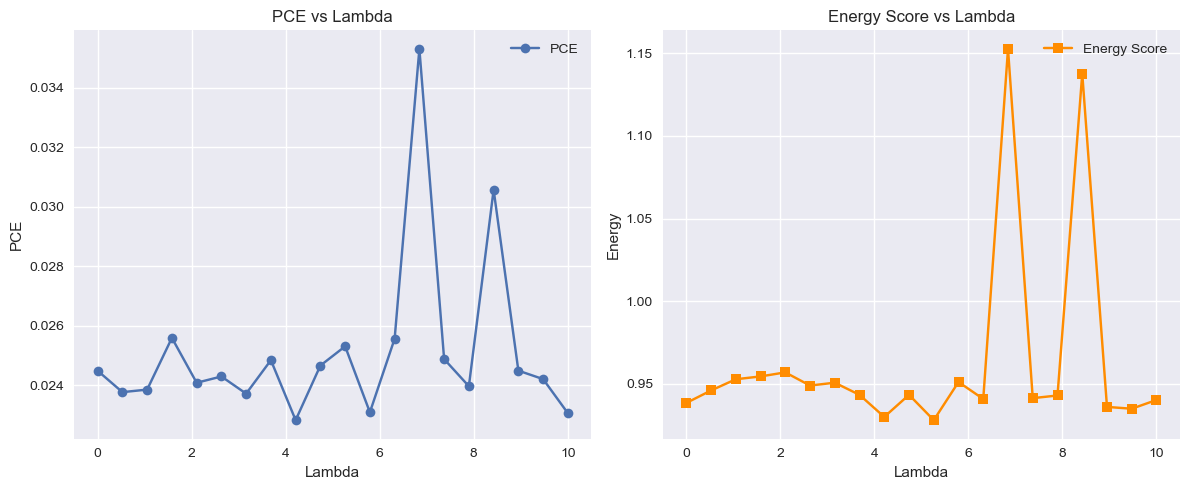

In [8]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))  # 2 subplots side by side

# Left plot: PCE
axes[0].plot(lambdas, pce_values, marker='o', label='PCE')
axes[0].set_xlabel('Lambda')
axes[0].set_ylabel('PCE')
axes[0].legend()
axes[0].set_title('PCE vs Lambda')
# axes[0].grid(True)

# Right plot: Energy Score
axes[1].plot(lambdas, nll_values, marker='s', color = 'darkorange', label='Energy Score')
axes[1].set_xlabel('Lambda')
axes[1].set_ylabel('Energy')
axes[1].legend()
axes[1].set_title('Energy Score vs Lambda')
# axes[1].grid(True)

plt.tight_layout()
# plt.savefig('figures/pce_energy_rqr_households.png', dpi=300)
plt.show()

In [9]:
with open('pkl-files/pce_energy_households_trunc.pkl', 'rb') as f:
    data = pickle.load(f)

In [10]:
threshold = data[0.0][1].item()*1.1
def best_lambda_under_threshold(results_dict, energy_threshold):
    selected_lambdas = {
        lam: (pce, energy)
        for lam, (pce, energy) in results_dict.items()
        if energy < energy_threshold
    }
    if not selected_lambdas:
        return 0.0  # or raise an error / return a default

    # Find the lambda with the lowest PCE among filtered ones
    return min(selected_lambdas.items(), key=lambda item: item[1][0])[0]
    

In [11]:
best_lambda = best_lambda_under_threshold(data, threshold)
best_lambda

4.2105263157894735